In [1]:
%%capture
!pip install librosa soundfile pytorch-grad-cam fastapi uvicorn python-multipart tqdm

In [2]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 55.5 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=d99ade3eb6d20a16947c7c9e00478f2aa14334f4dd67f964c47686452d3f569d
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


## Step 1: Data Discovery & Labeling



In [3]:
import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from tqdm.notebook import tqdm
from collections import defaultdict

import librosa
import librosa.display
import soundfile as sf

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f' Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

✅ Using device: cuda
PyTorch version: 2.10.0+cu128
CUDA available: True


In [4]:

FAKE_ROOT = Path('/kaggle/input/datasets/walimuhammadahmad/fakeaudio')   
REAL_ROOT = Path('/kaggle/input/datasets/mathurinache/the-lj-speech-dataset')
FEATURE_DIR = Path('/kaggle/working/features')
FEATURE_DIR.mkdir(exist_ok=True)


print(' Fake audio directories found:')
fake_dirs = sorted([d for d in FAKE_ROOT.iterdir() if d.is_dir()])
for d in fake_dirs:
    count = len(list(d.glob('**/*.wav')))
    print(f'  {d.name:35s} → {count:,} files')

print(f'\nTotal fake directories: {len(fake_dirs)}')

📁 Fake audio directories found:
  generated_audio                     → 134,266 files

Total fake directories: 1


In [5]:

import urllib.request, tarfile

LJ_URL = 'https://data.keithito.com/data/speech/LJSpeech-1.1.tar.bz2'
LJ_TAR = Path('/kaggle/working/LJSpeech-1.1.tar.bz2')
LJ_DIR = Path('/kaggle/working/ljspeech')

if not REAL_ROOT.exists():
    print('  Downloading LJSpeech (~2.6GB)...')
    urllib.request.urlretrieve(LJ_URL, LJ_TAR)
    print(' Extracting...')
    with tarfile.open(LJ_TAR, 'r:bz2') as tar:
        tar.extractall('/kaggle/working/')
    # Rename to consistent path
    Path('/kaggle/working/LJSpeech-1.1').rename(LJ_DIR)
    print(f' LJSpeech extracted → {REAL_ROOT}')
else:
    print(f' LJSpeech already available at {REAL_ROOT}')

real_files = list(REAL_ROOT.glob('**/*.wav'))
print(f'  Real audio files: {len(real_files):,}')

✅ LJSpeech already available at /kaggle/input/datasets/mathurinache/the-lj-speech-dataset
  Real audio files: 13,100


In [6]:
#Build master DataFrame (FIXED) 
records = []


for fp in real_files:
    records.append({
        'file_path': str(fp),
        'binary_label': 0,          # 0 = real
        'model_label': 'real',
    })


for fp in FAKE_ROOT.glob('**/*.wav'):
    records.append({
        'file_path': str(fp),
        'binary_label': 1,          # 1 = fake
        'model_label': fp.parent.name,  
    })

df = pd.DataFrame(records)

# Encode multi-class labels 
all_models = sorted(df['model_label'].unique())
model2idx = {m: i for i, m in enumerate(all_models)}
idx2model = {i: m for m, i in model2idx.items()}
df['class_id'] = df['model_label'].map(model2idx)

print(f'Total samples: {len(df):,}')
print(f'  Real: {(df.binary_label==0).sum():,}')
print(f'  Fake: {(df.binary_label==1).sum():,}')
print(f'\nClasses ({len(all_models)}):', all_models)
df.head()

Total samples: 147,366
  Real: 13,100
  Fake: 134,266

Classes (12): ['common_voices_prompts_from_conformer_fastspeech2_pwg_ljspeech', 'generated', 'jsut_multi_band_melgan', 'jsut_parallel_wavegan', 'ljspeech_full_band_melgan', 'ljspeech_hifiGAN', 'ljspeech_melgan', 'ljspeech_melgan_large', 'ljspeech_multi_band_melgan', 'ljspeech_parallel_wavegan', 'ljspeech_waveglow', 'real']


,file_path,binary_label,model_label,class_id
0,/kaggle/input/datasets/mathurinache/the-lj-spe...,0,real,11
1,/kaggle/input/datasets/mathurinache/the-lj-spe...,0,real,11
2,/kaggle/input/datasets/mathurinache/the-lj-spe...,0,real,11
3,/kaggle/input/datasets/mathurinache/the-lj-spe...,0,real,11
4,/kaggle/input/datasets/mathurinache/the-lj-spe...,0,real,11


In [7]:

N_REAL = min(len(df[df.binary_label==0]), len(df[df.binary_label==1]))
df_real = df[df.binary_label==0].sample(N_REAL, random_state=42)
df_fake = df[df.binary_label==1]
df_bal = pd.concat([df_real, df_fake]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f'Balanced dataset: {len(df_bal):,} samples')


train_df, temp_df = train_test_split(df_bal, test_size=0.2, stratify=df_bal['class_id'], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.5, stratify=temp_df['class_id'], random_state=42)
print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

Balanced dataset: 147,366 samples
Train: 117,892 | Val: 14,737 | Test: 14,737


##  Step 2: LFCC Feature Extraction



In [8]:

SAMPLE_RATE   = 16_000   
DURATION      = 4.0      
N_LFCC        = 60    
N_FFT         = 512
HOP_LENGTH    = 160      
N_MELS        = 128  
MAX_LEN       = int(SAMPLE_RATE * DURATION / HOP_LENGTH) + 1   


def extract_lfcc(file_path: str) -> np.ndarray | None:
    """
    Load audio → resample → trim/pad → compute LFCC.
    Returns: np.ndarray of shape (N_LFCC, MAX_LEN) or None on error.
    """
    try:
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)
        
      
        target = int(SAMPLE_RATE * DURATION)
        if len(y) > target:
            y = y[:target]
        else:
            y = np.pad(y, (0, target - len(y)))
        
     
        stft = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)) ** 2
        
   
        linear_fb = librosa.filters.mel(
            sr=SAMPLE_RATE, n_fft=N_FFT, n_mels=N_LFCC,
            htk=True, norm=None  
        )
        linear_spec = np.dot(linear_fb, stft)
        log_linear   = librosa.power_to_db(linear_spec + 1e-9)
        
        
        from scipy.fft import dct
        lfcc = dct(log_linear, type=2, axis=0, norm='ortho')[:N_LFCC]
        
   
        if lfcc.shape[1] < MAX_LEN:
            lfcc = np.pad(lfcc, ((0,0),(0, MAX_LEN - lfcc.shape[1])))
        else:
            lfcc = lfcc[:, :MAX_LEN]
        

        lfcc = (lfcc - lfcc.mean()) / (lfcc.std() + 1e-9)
        return lfcc.astype(np.float32)
    except Exception as e:
        return None



sample_path = df_bal['file_path'].iloc[0]
test_feat = extract_lfcc(sample_path)
print(f'LFCC feature shape: {test_feat.shape}')   # should be (60, ~401)
print(f'Value range: [{test_feat.min():.2f}, {test_feat.max():.2f}]')

LFCC feature shape: (60, 401)
Value range: [-13.10, 5.81]


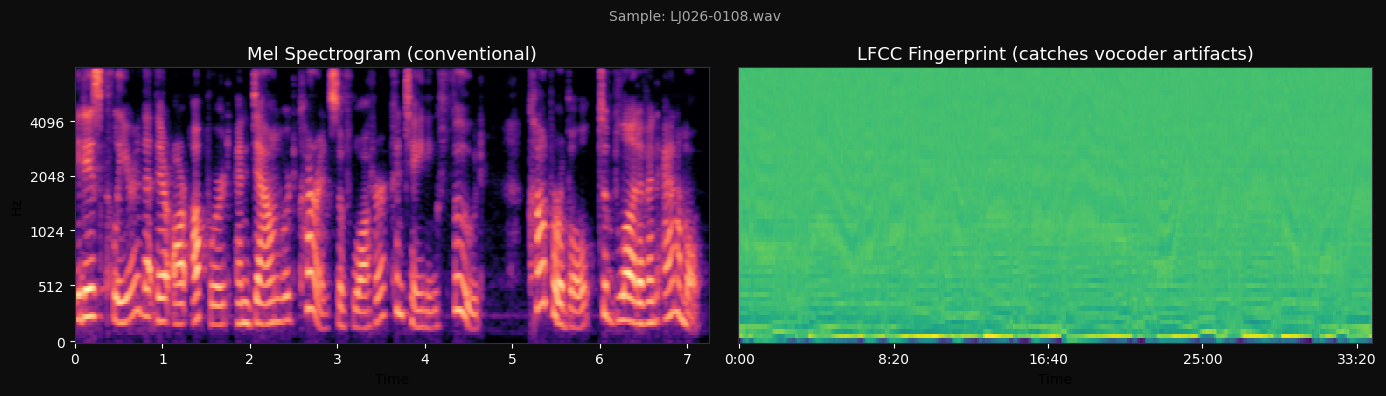

Saved → /kaggle/working/lfcc_vs_mel.png


In [9]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='#0d0d0d')

y, sr = librosa.load(sample_path, sr=SAMPLE_RATE)
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, hop_length=HOP_LENGTH)
mel_db = librosa.power_to_db(mel, ref=np.max)

librosa.display.specshow(mel_db, x_axis='time', y_axis='mel', sr=sr,
                          hop_length=HOP_LENGTH, ax=axes[0], cmap='magma')
axes[0].set_title('Mel Spectrogram (conventional)', color='white', fontsize=13)
axes[0].tick_params(colors='white')
axes[0].set_facecolor('#0d0d0d')

librosa.display.specshow(test_feat, x_axis='time', sr=sr / HOP_LENGTH,
                          ax=axes[1], cmap='viridis')
axes[1].set_title('LFCC Fingerprint (catches vocoder artifacts)', color='white', fontsize=13)
axes[1].tick_params(colors='white')
axes[1].set_facecolor('#0d0d0d')

for ax in axes:
    for spine in ax.spines.values():
        spine.set_edgecolor('#333')

plt.suptitle(f'Sample: {Path(sample_path).name}', color='#aaa', fontsize=10)
plt.tight_layout()
plt.savefig('/kaggle/working/lfcc_vs_mel.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print('Saved → /kaggle/working/lfcc_vs_mel.png')

In [10]:


def precompute_features(subset_df: pd.DataFrame, split_name: str):
    out_dir = FEATURE_DIR / split_name
    out_dir.mkdir(exist_ok=True)
    
    meta = []
    errors = 0
    for _, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc=f'Extracting {split_name}'):
        uid = Path(row['file_path']).stem
        npy_path = out_dir / f'{uid}.npy'
        
        if not npy_path.exists():
            feat = extract_lfcc(row['file_path'])
            if feat is None:
                errors += 1
                continue
            np.save(npy_path, feat)
        
        meta.append({
            'npy_path': str(npy_path),
            'binary_label': row['binary_label'],
            'class_id': row['class_id'],
            'model_label': row['model_label'],
        })
    
    meta_df = pd.DataFrame(meta)
    meta_df.to_csv(FEATURE_DIR / f'{split_name}_meta.csv', index=False)
    print(f'   {split_name}: {len(meta_df):,} saved | {errors} errors')
    return meta_df

train_meta = precompute_features(train_df, 'train')
val_meta   = precompute_features(val_df,   'val')
test_meta  = precompute_features(test_df,  'test')

Extracting train:   0%|          | 0/117892 [00:00<?, ?it/s]

  ✅ train: 117,892 saved | 0 errors


Extracting val:   0%|          | 0/14737 [00:00<?, ?it/s]

  ✅ val: 14,737 saved | 0 errors


Extracting test:   0%|          | 0/14737 [00:00<?, ?it/s]

  ✅ test: 14,737 saved | 0 errors


## Step 3: LCNN Architecture



In [11]:

class AudioForgeryDataset(Dataset):
    def __init__(self, meta_df: pd.DataFrame):
        self.data = meta_df.reset_index(drop=True)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        feat = np.load(row['npy_path'])         
        feat = torch.tensor(feat).unsqueeze(0)   
        return feat, int(row['binary_label']), int(row['class_id'])


BATCH_SIZE = 64
train_ds = AudioForgeryDataset(train_meta)
val_ds   = AudioForgeryDataset(val_meta)
test_ds  = AudioForgeryDataset(test_meta)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f'Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}')
print(f'Batch shape: {next(iter(train_loader))[0].shape}')

Train: 117,892 | Val: 14,737 | Test: 14,737
Batch shape: torch.Size([64, 1, 60, 401])


In [12]:
# 
class MFM(nn.Module):
    """
    Max-Feature-Map: splits channels in half and takes element-wise max.
    Acts as a competitive suppression layer — only the 'loudest' feature wins.
    This is what makes LCNN superior for audio forensics.
    """
    def forward(self, x):
        x1, x2 = torch.chunk(x, 2, dim=1)
        return torch.max(x1, x2)


# 
class LCNN(nn.Module):
    """
    Light CNN with dual-head output:
      - binary_logit  : Real (0) vs Fake (1)   → BCEWithLogitsLoss
      - source_logits : Which model made it?   → CrossEntropyLoss
    """
    def __init__(self, n_classes: int):
        super().__init__()
        
        # ── Convolutional backbone ──
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=5, padding=2),   # →  64ch
            MFM(),                                          # →  32ch
            nn.MaxPool2d(2, 2),                            # halve spatial

            nn.Conv2d(32, 128, kernel_size=1),
            MFM(),                                         # → 64ch
            nn.Conv2d(64, 96, kernel_size=3, padding=1),
            MFM(),                                         # → 48ch
            nn.MaxPool2d(2, 2),

            nn.Conv2d(48, 192, kernel_size=1),
            MFM(),                                         # → 96ch
            nn.Conv2d(96, 128, kernel_size=3, padding=1),
            MFM(),                                         # → 64ch
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=1),
            MFM(),                                         # → 64ch
            nn.Conv2d(64, 96, kernel_size=3, padding=1),
            MFM(),                                         # → 48ch
            nn.MaxPool2d(2, 2),

            nn.Conv2d(48, 256, kernel_size=1),
            MFM(),                                         # → 128ch
        )
        
        self.pool = nn.AdaptiveAvgPool2d((4, 4))          #  128*4*4 = 2048
        
        # ── Shared FC ──
        self.shared_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            MFM(),    # → 256
            nn.Dropout(0.5),
        )
        
        # Head 1: Binary (Real vs Fake) 
        self.binary_head = nn.Linear(256, 1)
        
        # Head 2: Multi-class (source model) 
        self.source_head = nn.Linear(256, n_classes)
    
    def forward(self, x):
        feat = self.backbone(x)
        feat = self.pool(feat)
        shared = self.shared_fc(feat)
        
        binary_logit  = self.binary_head(shared).squeeze(1)  
        source_logits = self.source_head(shared)             
        
        return binary_logit, source_logits


N_CLASSES = len(all_models)
model = LCNN(n_classes=N_CLASSES).to(DEVICE)
if torch.cuda.device_count() > 1:
    print(f"🚀 Using {torch.cuda.device_count()} GPUs: {[torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())]}")
    model = nn.DataParallel(model)
else:
    print(f"Running on single GPU: {torch.cuda.get_device_name(0)}")
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')


with torch.no_grad():
    dummy = torch.randn(4, 1, N_LFCC, MAX_LEN).to(DEVICE)
    b, s = model(dummy)
    print(f'Binary logit shape: {b.shape} | Source logit shape: {s.shape}')

🚀 Using 2 GPUs: ['Tesla T4', 'Tesla T4']
Model parameters: 1,310,093
Binary logit shape: torch.Size([4]) | Source logit shape: torch.Size([4, 12])


In [13]:
import torch.nn.functional as F


EPOCHS      = 30    
LR          = 1e-3
ALPHA       = 0.5   # weight: binary loss contribution
BETA        = 0.5   # weight: source loss contribution

optimizer   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler   = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)


source_loss_fn = nn.CrossEntropyLoss()

def train_one_epoch(loader):
    model.train()
    total_loss = total_bin_correct = total_src_correct = total = 0
    
    for feat, bin_lbl, src_lbl in loader:
        feat    = feat.to(DEVICE)
        bin_lbl = bin_lbl.float().to(DEVICE)
        src_lbl = src_lbl.long().to(DEVICE)
        
        optimizer.zero_grad()
        bin_logit, src_logit = model(feat)
        
       
        batch_weights = torch.where(bin_lbl == 0.0, 8.0, 1.0)
        bin_loss = F.binary_cross_entropy_with_logits(bin_logit, bin_lbl, weight=batch_weights)
        # ──────────────────────────────────────────────────────
        
        loss = ALPHA * bin_loss + BETA * source_loss_fn(src_logit, src_lbl)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * len(feat)
        total_bin_correct += ((bin_logit > 0).long() == bin_lbl.long()).sum().item()
        total_src_correct += (src_logit.argmax(1) == src_lbl).sum().item()
        total += len(feat)
    
    scheduler.step()
    return total_loss/total, total_bin_correct/total, total_src_correct/total

@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss = total_bin_correct = total_src_correct = total = 0
    
    for feat, bin_lbl, src_lbl in loader:
        feat    = feat.to(DEVICE)
        bin_lbl = bin_lbl.float().to(DEVICE)
        src_lbl = src_lbl.long().to(DEVICE)
        
        bin_logit, src_logit = model(feat)
        
     
        batch_weights = torch.where(bin_lbl == 0.0, 8.0, 1.0)
        bin_loss = F.binary_cross_entropy_with_logits(bin_logit, bin_lbl, weight=batch_weights)
       
        loss = ALPHA * bin_loss + BETA * source_loss_fn(src_logit, src_lbl)
        
        total_loss += loss.item() * len(feat)
        total_bin_correct += ((bin_logit > 0).long() == bin_lbl.long()).sum().item()
        total_src_correct += (src_logit.argmax(1) == src_lbl).sum().item()
        total += len(feat)
    
    return total_loss/total, total_bin_correct/total, total_src_correct/total

print('Training setup ready ✅')

Training setup ready ✅


In [14]:

from collections import defaultdict

history = defaultdict(list)
best_combined_score = 0  
BEST_MODEL_PATH = '/kaggle/working/best_lcnn.pth'

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_bin, tr_src = train_one_epoch(train_loader)
    vl_loss, vl_bin, vl_src = evaluate(val_loader)
    
    history['tr_loss'].append(tr_loss)
    history['vl_loss'].append(vl_loss)
    history['tr_bin'].append(tr_bin)
    history['vl_bin'].append(vl_bin)
    history['tr_src'].append(tr_src)
    history['vl_src'].append(vl_src)
    
  
    current_score = vl_bin + vl_src 
    
    if current_score > best_combined_score:
        best_combined_score = current_score
       
        torch.save(model.module.state_dict(), BEST_MODEL_PATH)
        saved_marker = '💾'
    else:
        saved_marker = ''
    
    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Loss: {tr_loss:.4f}/{vl_loss:.4f} | '
          f'BinAcc: {tr_bin:.3f}/{vl_bin:.3f} | '
          f'SrcAcc: {tr_src:.3f}/{vl_src:.3f} {saved_marker}')

print(f'\n Best Combined Val Score: {best_combined_score:.4f}')

Epoch 01/30 | Loss: 1.1242/0.8756 | BinAcc: 0.783/0.803 | SrcAcc: 0.307/0.419 💾
Epoch 02/30 | Loss: 0.7818/0.7323 | BinAcc: 0.894/0.889 | SrcAcc: 0.396/0.453 💾
Epoch 03/30 | Loss: 0.7292/0.6857 | BinAcc: 0.903/0.901 | SrcAcc: 0.408/0.417 
Epoch 04/30 | Loss: 0.7120/0.6757 | BinAcc: 0.905/0.905 | SrcAcc: 0.414/0.475 💾
Epoch 05/30 | Loss: 0.7073/0.6631 | BinAcc: 0.906/0.908 | SrcAcc: 0.415/0.454 
Epoch 06/30 | Loss: 0.6955/0.6596 | BinAcc: 0.907/0.908 | SrcAcc: 0.420/0.545 💾
Epoch 07/30 | Loss: 0.6886/0.6644 | BinAcc: 0.908/0.907 | SrcAcc: 0.420/0.532 
Epoch 08/30 | Loss: 0.6918/0.6629 | BinAcc: 0.907/0.910 | SrcAcc: 0.422/0.502 
Epoch 09/30 | Loss: 0.6836/0.6605 | BinAcc: 0.909/0.901 | SrcAcc: 0.424/0.474 
Epoch 10/30 | Loss: 0.6820/0.6588 | BinAcc: 0.909/0.910 | SrcAcc: 0.425/0.601 💾
Epoch 11/30 | Loss: 0.6796/0.7627 | BinAcc: 0.909/0.907 | SrcAcc: 0.426/0.530 
Epoch 12/30 | Loss: 0.6767/0.6222 | BinAcc: 0.909/0.910 | SrcAcc: 0.426/0.607 💾
Epoch 13/30 | Loss: 0.6707/0.6320 | BinAcc: 0.

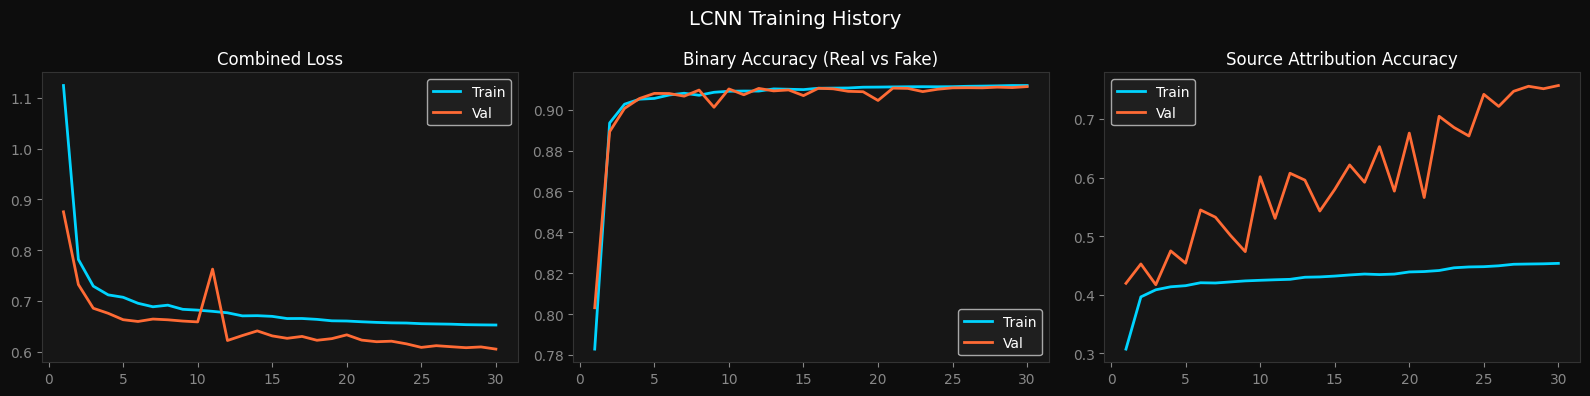

In [15]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='#0d0d0d')
colors = {'train': '#00d4ff', 'val': '#ff6b35'}

for ax in axes:
    ax.set_facecolor('#161616')
    ax.tick_params(colors='#888')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333')

epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history['tr_loss'], color=colors['train'], label='Train', linewidth=2)
axes[0].plot(epochs_range, history['vl_loss'], color=colors['val'],   label='Val',   linewidth=2)
axes[0].set_title('Combined Loss', color='white'); axes[0].legend(facecolor='#222', labelcolor='white')

axes[1].plot(epochs_range, history['tr_bin'], color=colors['train'], label='Train', linewidth=2)
axes[1].plot(epochs_range, history['vl_bin'], color=colors['val'],   label='Val',   linewidth=2)
axes[1].set_title('Binary Accuracy (Real vs Fake)', color='white'); axes[1].legend(facecolor='#222', labelcolor='white')

axes[2].plot(epochs_range, history['tr_src'], color=colors['train'], label='Train', linewidth=2)
axes[2].plot(epochs_range, history['vl_src'], color=colors['val'],   label='Val',   linewidth=2)
axes[2].set_title('Source Attribution Accuracy', color='white'); axes[2].legend(facecolor='#222', labelcolor='white')

plt.suptitle('LCNN Training History', color='white', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

##  Step 4: Evaluation on Test Set

In [16]:

model.module.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

all_bin_true, all_bin_pred = [], []
all_src_true, all_src_pred = [], []

with torch.no_grad():
    for feat, bin_lbl, src_lbl in tqdm(test_loader, desc='Testing'):
        feat = feat.to(DEVICE)
        bin_logit, src_logit = model(feat)
        
        all_bin_true.extend(bin_lbl.numpy())
        all_bin_pred.extend((bin_logit.cpu() > 0).long().numpy())
        all_src_true.extend(src_lbl.numpy())
        all_src_pred.extend(src_logit.cpu().argmax(1).numpy())

print('═' * 60)
print('PHASE 1 — Binary Classification (Real vs Fake)')
print('═' * 60)
print(classification_report(all_bin_true, all_bin_pred, target_names=['Real', 'Fake']))

print('═' * 60)
print('PHASE 2 — Source Model Attribution')
print('═' * 60)
print(classification_report(all_src_true, all_src_pred, target_names=all_models))

Testing:   0%|          | 0/231 [00:00<?, ?it/s]

════════════════════════════════════════════════════════════
PHASE 1 — Binary Classification (Real vs Fake)
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

        Real       0.50      0.99      0.66      1310
        Fake       1.00      0.90      0.95     13427

    accuracy                           0.91     14737
   macro avg       0.75      0.95      0.81     14737
weighted avg       0.95      0.91      0.92     14737

════════════════════════════════════════════════════════════
PHASE 2 — Source Model Attribution
════════════════════════════════════════════════════════════
                                                               precision    recall  f1-score   support

common_voices_prompts_from_conformer_fastspeech2_pwg_ljspeech       0.42      0.01      0.02      1629
                                                    generated       0.50      0.98      0.66      1628
                                     

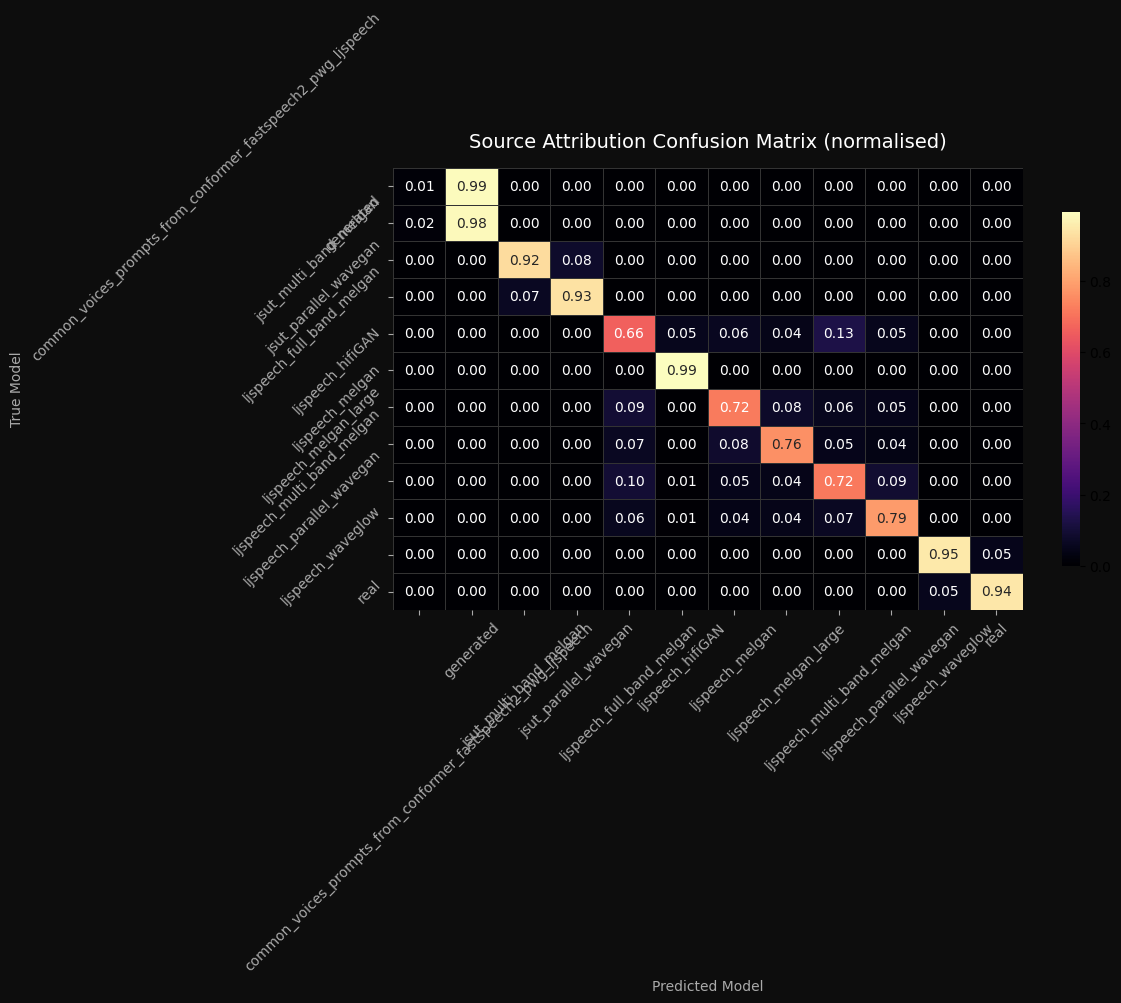

In [17]:

cm_src = confusion_matrix(all_src_true, all_src_pred)
cm_norm = cm_src.astype('float') / cm_src.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(12, 10), facecolor='#0d0d0d')
ax.set_facecolor('#0d0d0d')
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='magma',
    xticklabels=all_models, yticklabels=all_models,
    ax=ax, linewidths=0.5, linecolor='#333',
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Source Attribution Confusion Matrix (normalised)', color='white', fontsize=14, pad=15)
ax.set_xlabel('Predicted Model', color='#aaa')
ax.set_ylabel('True Model', color='#aaa')
ax.tick_params(colors='#aaa', rotation=45)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

##  Step 5: Explainable AI Grad-CAM Spectrogram Highlighting



Sample 1: LJ037-0222_gen.wav | True: ljspeech_multi_band_melgan


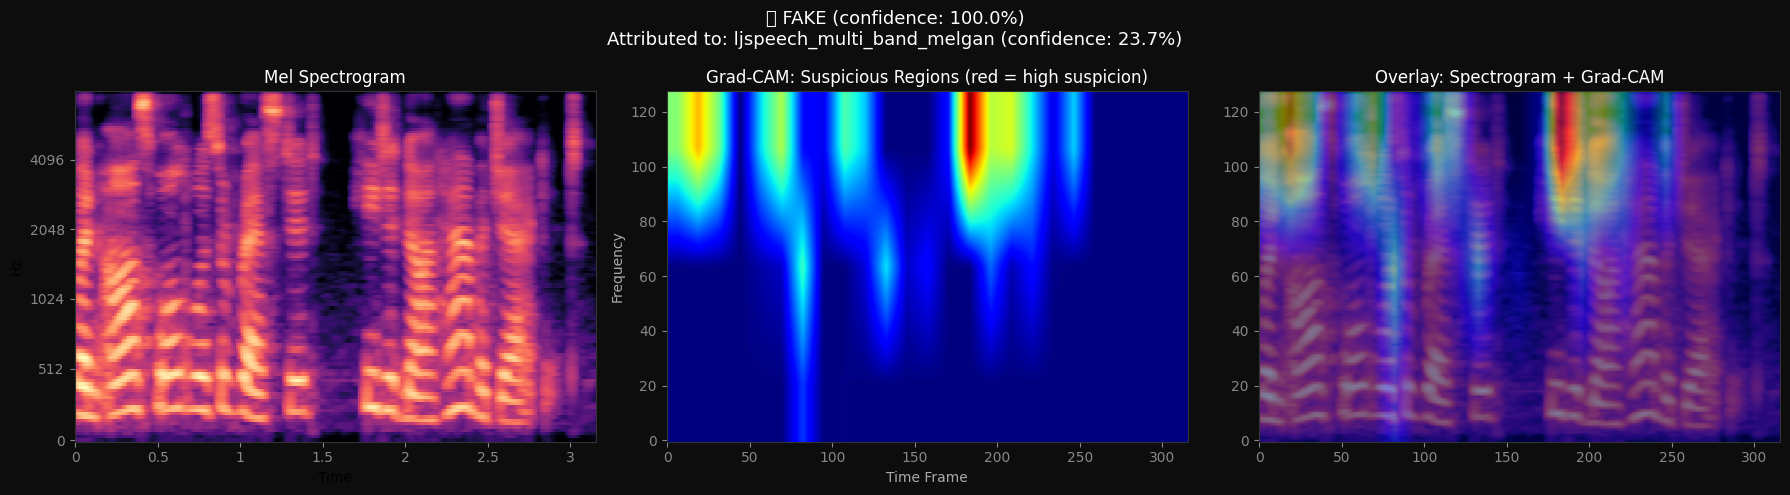

  → 🔴 FAKE  |  Model: ljspeech_multi_band_melgan  |  Prob fake: 1.000

Sample 2: LJ028-0343.wav | True: real


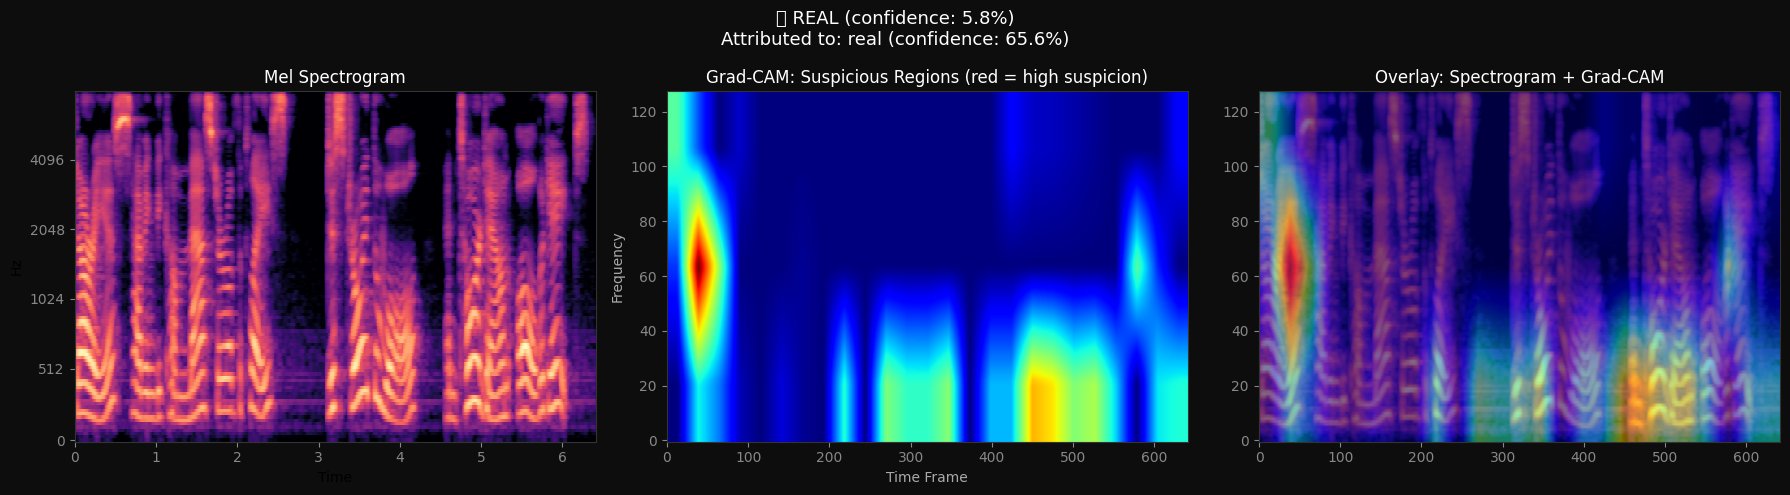

  → 🟢 REAL  |  Model: real  |  Prob fake: 0.058

Sample 3: LJ029-0167_gen.wav | True: ljspeech_melgan


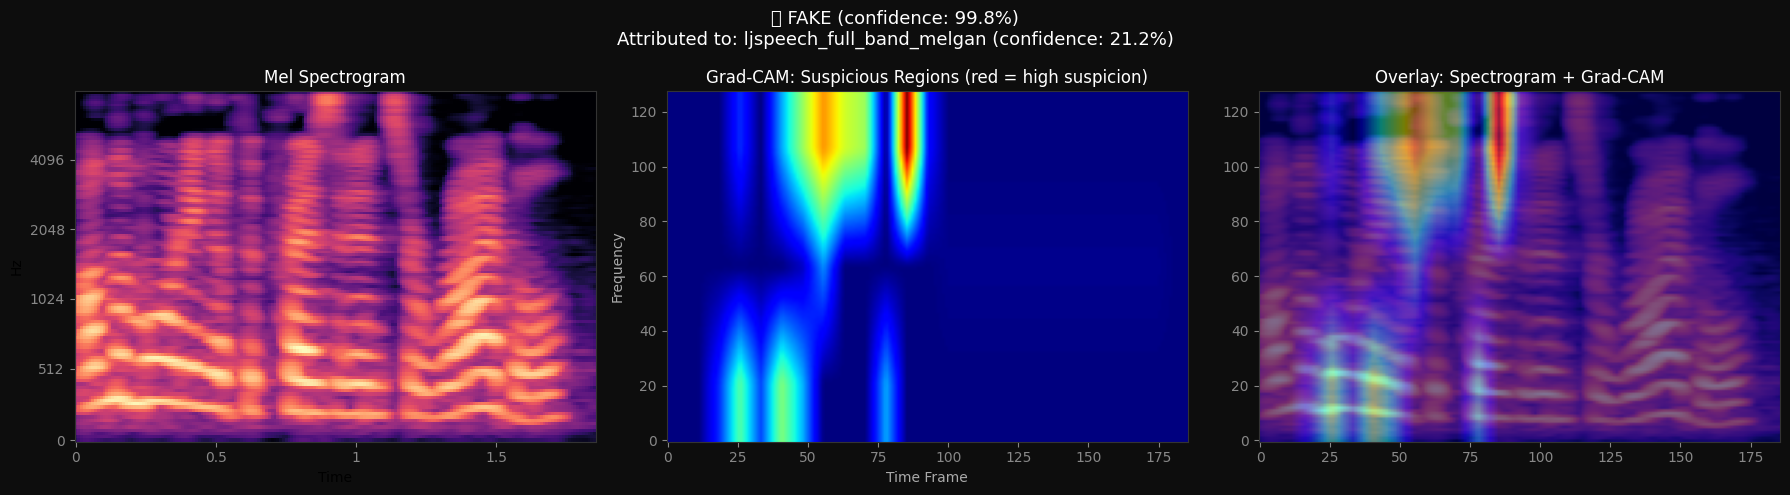

  → 🔴 FAKE  |  Model: ljspeech_full_band_melgan  |  Prob fake: 0.998


In [18]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import cv2



class BinaryLCNNWrapper(nn.Module):
    """Wraps LCNN to expose only the binary logit for Grad-CAM."""
    def __init__(self, lcnn):
        super().__init__()
        self.lcnn = lcnn
    
    def forward(self, x):
        bin_logit, _ = self.lcnn(x)
        return bin_logit.unsqueeze(1)   # (B, 1)


wrapped = BinaryLCNNWrapper(model)


target_layer = model.module.backbone[-2]   

cam = GradCAM(model=wrapped, target_layers=[target_layer])


def explain_prediction(audio_path: str, save_path: str = None):
    """Run Grad-CAM on a single audio file and overlay on spectrogram."""
    # Extract features
    lfcc = extract_lfcc(audio_path)
    if lfcc is None:
        print('Feature extraction failed.')
        return
    
    input_tensor = torch.tensor(lfcc).unsqueeze(0).unsqueeze(0).to(DEVICE)  
    

    model.eval()
    with torch.no_grad():
        bin_logit, src_logit = model(input_tensor)
    
    prob_fake = torch.sigmoid(bin_logit).item()
    pred_class = src_logit.argmax(1).item()
    pred_model = idx2model[pred_class]
    src_conf   = F.softmax(src_logit, dim=1).max().item()
    

    targets = [ClassifierOutputTarget(0)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]  # (F, T)
    
   
    y, sr = librosa.load(audio_path, sr=SAMPLE_RATE)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0d0d0d')
    
    # Spectrogram
    librosa.display.specshow(mel_db, x_axis='time', y_axis='mel', sr=sr,
                              hop_length=HOP_LENGTH, ax=axes[0], cmap='magma')
    axes[0].set_title('Mel Spectrogram', color='white')
    
    # Grad-CAM heatmap
    heatmap = cv2.resize(grayscale_cam, (mel_db.shape[1], mel_db.shape[0]))
    axes[1].imshow(heatmap, aspect='auto', origin='lower', cmap='jet', interpolation='bilinear')
    axes[1].set_title('Grad-CAM: Suspicious Regions (red = high suspicion)', color='white')
    axes[1].set_xlabel('Time Frame', color='#aaa')
    axes[1].set_ylabel('Frequency', color='#aaa')
    
    # Overlay
    spec_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-9)
    axes[2].imshow(spec_norm, aspect='auto', origin='lower', cmap='magma')
    axes[2].imshow(heatmap, aspect='auto', origin='lower', cmap='jet', alpha=0.5)
    axes[2].set_title('Overlay: Spectrogram + Grad-CAM', color='white')
    
    for ax in axes:
        ax.set_facecolor('#0d0d0d')
        ax.tick_params(colors='#888')
        for sp in ax.spines.values(): sp.set_edgecolor('#333')
    
    verdict = ' FAKE' if prob_fake > 0.5 else 'REAL'
    title = (f'{verdict} (confidence: {prob_fake:.1%})\n'
             f'Attributed to: {pred_model} (confidence: {src_conf:.1%})')
    plt.suptitle(title, color='white', fontsize=13)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()
    print(f'  → {verdict}  |  Model: {pred_model}  |  Prob fake: {prob_fake:.3f}')
    return prob_fake, pred_model, src_conf



for i, (_, row) in enumerate(test_meta.sample(3, random_state=1).iterrows()):
    audio_path = row['npy_path'].replace('.npy', '.wav')   # recover original
    
    src_df = test_df[test_df['class_id'] == row['class_id']].sample(1).iloc[0]
    print(f'\nSample {i+1}: {Path(src_df.file_path).name} | True: {src_df.model_label}')
    explain_prediction(src_df['file_path'], save_path=f'/kaggle/working/gradcam_{i+1}.png')

In [65]:
import torch
import numpy as np
import pandas as pd

# 1. Initialize Model and Load Weights (Done once for efficiency)
model = LCNN(n_classes=12).to(DEVICE)
model.load_state_dict(torch.load('best_lcnn.pth', map_location=DEVICE))
model.eval()

# 2. Select 10 random samples from the test metadata
samples = test_meta.sample(10)
results = []

print(f"Processing 10 random samples for evaluation...")

# 3. Perform Batch Prediction
with torch.no_grad():
    for _, row in samples.iterrows():
        # Load and preprocess features
        feat = np.load(row['npy_path'])
        feat_tensor = torch.tensor(feat).unsqueeze(0).unsqueeze(0).to(DEVICE)
        
        # Model forward pass
        bin_logit, src_logit = model(feat_tensor)
        
        # Process Binary Prediction (Real vs Fake)
        is_fake_pred = torch.sigmoid(bin_logit).item() > 0.5
        pred_binary = 'Fake' if is_fake_pred else 'Real'
        actual_binary = 'Fake' if row['binary_label'] == 1 else 'Real'
        
        # Process Source Prediction (AI Model Attribution)
        pred_model_idx = src_logit.argmax(1).item()
        pred_model_name = idx2model[pred_model_idx]
        actual_model_name = row['model_label']
        
        # Store results for the table
        results.append({
            "File Name": row['npy_path'].split('/')[-1], # Clean file name
            "Actual (Binary)": actual_binary,
            "Predicted (Binary)": pred_binary,
            "Actual (Source)": actual_model_name,
            "Predicted (Source)": pred_model_name,
            "Correct?": "✅" if (actual_binary == pred_binary and actual_model_name == pred_model_name) else "❌"
        })

# 4. Display Results as a Table
results_df = pd.DataFrame(results)
display(results_df)

Processing 10 random samples for evaluation...


,File Name,Actual (Binary),Predicted (Binary),Actual (Source),Predicted (Source),Correct?
0,gen_15198.npy,Fake,Fake,generated,generated,✅
1,BASIC5000_4911_gen.npy,Fake,Fake,jsut_parallel_wavegan,jsut_parallel_wavegan,✅
2,LJ046-0097_gen.npy,Fake,Fake,ljspeech_multi_band_melgan,ljspeech_multi_band_melgan,✅
3,LJ038-0064.npy,Real,Real,real,real,✅
4,gen_9164.npy,Fake,Fake,common_voices_prompts_from_conformer_fastspeec...,generated,❌
5,LJ014-0090_gen.npy,Fake,Fake,ljspeech_melgan_large,ljspeech_melgan_large,✅
6,LJ044-0083_gen.npy,Fake,Fake,ljspeech_parallel_wavegan,ljspeech_full_band_melgan,❌
7,LJ048-0235_gen.npy,Fake,Fake,ljspeech_melgan_large,ljspeech_melgan_large,✅
8,LJ021-0131_gen.npy,Fake,Fake,ljspeech_full_band_melgan,ljspeech_full_band_melgan,✅
9,gen_13049.npy,Fake,Fake,generated,generated,✅
